# Notebook 7 — Correlation & Regression: Inference vs Prediction

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 7 — Correlation & Regression**. The lecture covered Pearson vs. Spearman correlation, the linear regression model (least squares, residuals, assumptions), cases where linear regression fails on low-dimensional data (e.g. circular relationships), polynomial terms and interactions, and robust regression for outliers and heavy tails.

In this notebook we put those ideas into practice on a behavioural dataset, and along the way we build up the coding skills that go with them: scatter plots, correlation functions, `statsmodels` regression and design matrices, polynomial fits, train/test splits, cross-validation, and residual diagnostics.

> **A note on the dataset.** For this draft we use a **synthetic** dataset built to have the right statistical properties (a linear trend with noise and outliers, a sigmoidal accuracy curve, and a circular variable). The final version will load real behavioural data (e.g. from the [IBL](https://www.internationalbrainlab.com/) task) with `pd.read_csv(...)` in place of Section 2's simulation cell. Most columns map over directly (a few field names will be renamed downstream — the dataset author can help with that). The **one exception is the circular variable**: the IBL 2-alternative forced-choice task has no orientation/phase to estimate, so **Section 8 stays a small self-contained synthetic add-on** rather than being swapped for real data.

### By the end of this notebook you will be able to
- Build scatter plots to inspect a bivariate relationship before modelling it.
- Compute **covariance** and build **Pearson's r** from scratch, and know when to prefer **Spearman**.
- Fit a linear regression with `statsmodels`, understand the **design matrix**, and interpret coefficients.
- Do **inference on a slope**: standard error, *t*-statistic, *p*-value, and 95% confidence interval.
- Recognise when linear regression **fails** on low-dimensional data, e.g. circular/periodic relationships.
- Add **polynomial terms** and **interactions**, and know when they help vs. when they overfit.
- Use a **train/test split** and **k-fold cross-validation** to distinguish *inference* from *prediction*.
- Use **residual diagnostics** (residuals vs. fitted, Q-Q plots, Cook's distance) to check assumptions.
- Apply **robust regression** to handle outliers and influential points.

### Table of contents
1. [The scientific context: behaviour, correlation, and regression](#section-1)
2. [Setting up the workspace and simulating the data](#section-2)
3. [Scatter plots](#section-3)
4. [Correlation: covariance, Pearson, and Spearman](#section-4)
5. [Linear regression: model, design matrix, least squares, inference](#section-5)
6. [Design matrices: a worked example](#section-6)
7. [Residual diagnostics](#section-7)
8. [When linear regression fails: circular relationships (synthetic add-on)](#section-8)
9. [Polynomial terms and interactions](#section-9)
10. [Train/test split and cross-validation: inference vs. prediction](#section-10)
11. [Robust regression: outliers and influential points](#section-11)
12. [Putting it all together: a mini-analysis](#section-12)
13. [Wrap-up and discussion](#section-13)

> **How to read this notebook.** Markdown cells explain the *concept*; code cells implement it. Look out for **`▶ Task`** boxes: those are short exercises. Some ask you to **run** provided code and interpret it; others ask you to **write** or **repair** code yourself. Write your answers in the **Response** cells.
>
> **Difficulty tags.** Each task is tagged **⭐ (warm-up)**, **⭐⭐ (core)**, or **⭐⭐⭐ (challenge — do these if you have time, or continue at home)**.
>
> If you get stuck, ask the TAs. If you use AI help, treat it as a tutor, not as a replacement for thinking: you should still be able to read each line of code and explain what it does. Our custom GPT bot tuned for this course is here: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot


<a id="section-1"></a>
## 1. The scientific context: behaviour, correlation, and regression

A huge amount of behavioural neuroscience comes down to asking: *does variable X relate to variable Y, and can I describe that relationship with a model?* Two example questions from a typical psychophysics session (such as in [Plainis & Murray, 2000](https://doi.org/10.1016/S0028-3932(00)00100-7)), where a participant is requested to respond upon presentation of a stimulus with variable contrast (i.e. visual vividness), could be:

- Does **reaction time** get shorter as **stimulus contrast** increases, and how strong is that relationship?
- Can I **predict** a subject's choice accuracy from the contrast of the stimulus they just saw?

The first question is mostly about *inference*: we are looking for a number (a correlation, a slope) that summarises a relationship we can interpret and report. The second is more about *prediction*: we want to define a model that generalises well to new trials. Keeping this distinction in mind will matter throughout the notebook, especially once we get to train/test splits and cross-validation in Section 10.

Not every relationship is linear, and not every variable behaves like an ordinary number — for instance, an **orientation** or **phase** variable wraps around itself (0° and 360° are the same point), which breaks the assumptions of an ordinary linear fit. We will see this failure mode explicitly in Section 8.


<a id="section-2"></a>
## 2. Setting up the workspace and simulating the data

> **Before you run anything**, make sure the course conda environment (`qmn`) is activated / selected as the kernel of this notebook, as described in Notebook 1.

As usual, we start by importing the libraries we need. On top of `numpy`, `pandas`, and `matplotlib`, this week we bring in `scipy.stats` (correlation functions), `statsmodels` (regression models and design matrices), and `sklearn.model_selection` (splitting data into train/test and cross-validation folds).


In [1]:
# --- Import the core scientific Python stack
import numpy as np                              # for numerical computing
import pandas as pd                             # for data manipulation and analysis
import matplotlib.pyplot as plt                 # for plotting
from cycler import cycler                       # for custom colours in plots
import scipy.stats as stats                     # correlation functions
import statsmodels.api as sm                    # regression models, design matrices
import statsmodels.formula.api as smf           # R-style formula interface
from sklearn.model_selection import train_test_split, KFold  # train/test split + cross-validation

# A little bit of style for the plots (same palette as previous notebooks)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#5b2c83",  # purple
    ]),
})

np.random.seed(7)

print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")
print(f"statsmodels : {sm.__version__}")


NumPy       : 2.3.5
pandas      : 3.0.3
matplotlib  : 3.11.0
statsmodels : 0.14.6


Now we build the dataset. We simulate `n_subjects` subjects each completing `trials_per_subject` trials of a contrast-detection task, giving us:

- `contrast`: stimulus contrast (0 to 1)
- `reaction_time`: decreases roughly linearly with contrast, plus subject-level noise and a handful of slow "lapse" trials (outliers)
- `accuracy_prob`: the idealised, noiseless psychometric curve — a **nonlinear** (sigmoidal) function of contrast ([what is a sigmoidal function?](https://en.wikipedia.org/wiki/Sigmoid_function)). Because it is a *perfect* function of contrast, it is only shown for reference; we do not analyse it (see the warning below).
- `accuracy_obs`: **observed accuracy** — the same sigmoidal curve plus trial-to-trial fluctuation in attention/arousal, and a ceiling near 1. This is the realistic behavioural measure we use in Sections 4 and 9.
- `correct_choice`: the 0/1 outcome recorded on each trial (drawn using `accuracy_obs`)
- `stim_angle` / `response_angle`: the true orientation of a stimulus (0–360°) and the subject's noisy estimate of it — a **circular** variable we will come back to in Section 8

> **TODO (final version).** Replace this whole cell with a single line, e.g. `df = pd.read_csv("data/psychophysics_regression.csv")`. Everything downstream works unchanged as long as the column names match; the dataset author will help rename a few fields. Keep `stim_angle`/`response_angle` synthetic (the real IBL task has no circular variable).


In [2]:
# --- Simulate a synthetic psychophysics-style dataset
n_subjects = 12                       # how many subjects
trials_per_subject = 60               # how many trials per subject
n = n_subjects * trials_per_subject

subject_id = np.repeat(np.arange(n_subjects), trials_per_subject)                       # mock subject IDs
subject_intercept = np.repeat(np.random.normal(0, 0.05, n_subjects), trials_per_subject)  # random intercept per participant

contrast = np.random.uniform(0, 1, n)   # random contrast variable

# Reaction time: faster with higher contrast, plus noise and a few "lapse" outliers
rt_noise = np.random.normal(0, 0.05, n)
reaction_time = 0.9 - 0.5 * contrast + subject_intercept + rt_noise
lapse_idx = np.random.choice(n, size=int(0.03 * n), replace=False)
reaction_time[lapse_idx] += np.random.uniform(0.5, 1.5, size=len(lapse_idx))
reaction_time = np.clip(reaction_time, 0.15, None)

# Choice accuracy: a sigmoidal (nonlinear) function of contrast, PLUS trial-to-trial
# fluctuation in attention/arousal, so performance is not a perfect function of contrast.
logit = 6 * (contrast - 0.3)
accuracy_prob = 1 / (1 + np.exp(-logit))                   # noiseless sigmoid (the "ideal" psychometric curve)
attention_noise = np.random.normal(0, 0.05, n)             # fluctuating attentional state
accuracy_obs = np.clip(accuracy_prob + attention_noise, 0.01, 0.99)  # observed accuracy, with a ceiling
correct_choice = np.random.binomial(1, accuracy_obs)       # the 0/1 outcome recorded on each trial

# Circular variable: stimulus orientation and a noisy response estimate
stim_angle = np.random.uniform(0, 360, n)
angle_noise = np.random.normal(0, 20, n)
response_angle = (stim_angle + angle_noise) % 360

# We wrap our dataset in a dataframe class to make it more easily manageable
df = pd.DataFrame({
    "subject_id": subject_id,
    "contrast": contrast,
    "reaction_time": reaction_time,
    "accuracy_prob": accuracy_prob,
    "accuracy_obs": accuracy_obs,
    "correct_choice": correct_choice,
    "stim_angle": stim_angle,
    "response_angle": response_angle,
})

print(f"Shape (rows, columns): {df.shape}")
df.head(10)   # print the first 10 rows to check what came out


Shape (rows, columns): (720, 8)


,subject_id,contrast,reaction_time,accuracy_prob,accuracy_obs,correct_choice,stim_angle,response_angle
0,0,0.288146,0.831263,0.482226,0.492831,0,342.100182,318.802549
1,0,0.909594,0.459062,0.974853,0.990000,1,98.796129,97.496328
2,0,0.213385,1.003374,0.372925,0.372110,1,286.521648,274.197713
3,0,0.452124,0.782220,0.713561,0.671269,1,179.019930,191.289558
4,0,0.931206,0.563654,0.977844,0.922592,1,211.482090,222.816439
5,0,0.024899,1.004978,0.161027,0.136295,1,87.661673,67.458348
6,0,0.600549,0.730914,0.858549,0.863821,1,76.129932,59.343447
7,0,0.950130,0.539866,0.980175,0.913645,1,75.980497,93.428405
8,0,0.230303,0.852615,0.396952,0.357997,0,129.119662,134.253167
9,0,0.548490,0.747482,0.816219,0.838294,1,270.840500,255.784640


> **⚠ A note on `accuracy_prob` vs. `accuracy_obs`.** `accuracy_prob` is a *deterministic, noiseless* function of `contrast`: as contrast goes up, it goes up, always, with no exceptions. Correlating the two would give a Spearman coefficient of **exactly 1.000** — but that is an artefact of how the variable was built, not a scientific finding, and no real behavioural measure looks like that.
>
> Real performance fluctuates: attention drifts, subjects blink, motivation varies. `accuracy_obs` adds exactly that — the same underlying sigmoidal curve, plus trial-to-trial noise, plus a natural ceiling near 1 (at high contrast the task is easy and subjects are near-perfect). **Throughout this notebook we analyse `accuracy_obs`, never `accuracy_prob`.**


<a id="section-3"></a>
## 3. Scatter plots

Before fitting any model, it is always a good idea to actually **look at the data**. A scatter plot reveals the shape of a relationship (linear? curved? circular? unclear?), the spread of the noise, and any obvious outliers — all things that a correlation coefficient alone can hide. It also tells you, before you run any complicated analysis, whether your data look reasonable :D


> **▶ Task 3.1 ⭐ — Repair the bug.**
> The cell below is *meant* to draw a scatter plot of **reaction time (y-axis)** against **contrast (x-axis)**, but it has bugs: the data passed to `scatter` are on the wrong axes, so the plot does not match its labels and title. **Fix the cell** so that contrast is on the x-axis and reaction time on the y-axis.
> Once it is fixed: does the relationship look roughly linear? Do you see anything that looks like an outlier?


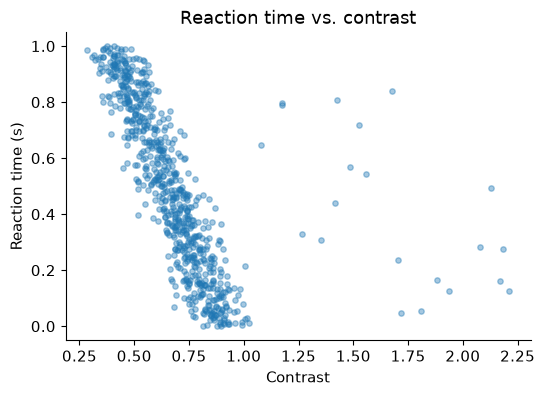

In [3]:
# TODO 3.1 — this cell has a bug: the x and y data are swapped relative to the labels/title.
#            Fix it so contrast is on x and reaction_time is on y, then run it.
fig, ax = plt.subplots()
ax.scatter(df["reaction_time"], df["contrast"], alpha=0.4, s=15)   # <-- x and y are swapped here
ax.set_xlabel("Contrast")
ax.set_ylabel("Reaction time (s)")
ax.set_title("Reaction time vs. contrast")
plt.show()


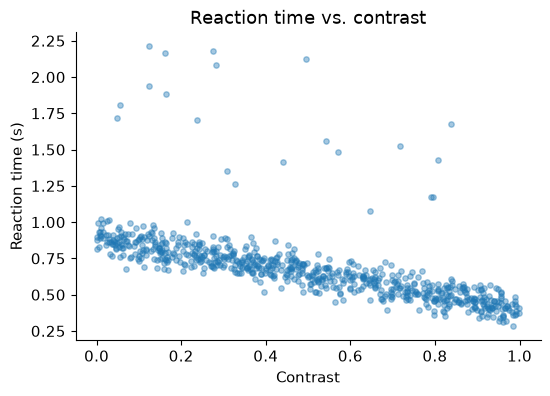

In [4]:
# Solution 3.1
fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["reaction_time"], alpha=0.4, s=15)   # contrast on x, reaction_time on y
ax.set_xlabel("Contrast")
ax.set_ylabel("Reaction time (s)")
ax.set_title("Reaction time vs. contrast")
plt.show()
# Bug fixed: the arguments to scatter were swapped relative to the axis labels.
# The relationship looks roughly linear (RT falls as contrast rises), and a few points
# sit well above the trend -- those are the injected "lapse" outliers.


**▶ Task 3.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 3.2 ⭐ — Stimulus vs. response angle.**
> Make the same kind of scatter plot for `stim_angle` (x-axis) against `response_angle` (y-axis).
> What looks different about this relationship compared to Task 3.1, especially near the edges of the axis range (close to 0° and close to 360°)?


In [5]:
# TODO 3.2 — write your code here



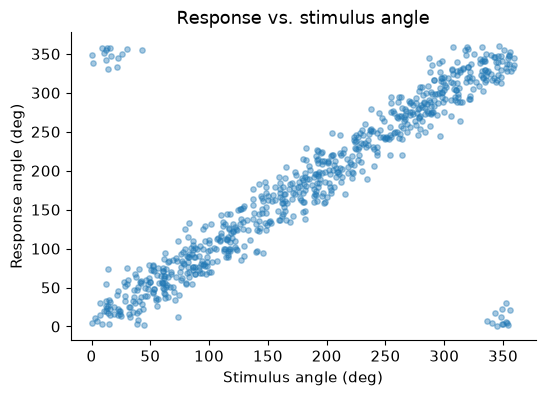

In [6]:
# Solution 3.2
fig, ax = plt.subplots()
ax.scatter(df["stim_angle"], df["response_angle"], alpha=0.4, s=15)
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.set_title("Response vs. stimulus angle")
plt.show()
# Note the wrap-around: points near 0 and 360 are geometrically close together,
# but the scatter plot (and any linear model) treats them as being at opposite ends.


**▶ Task 3.2 — Response: (Write your response in this Markdown cell)**

<a id="section-4"></a>
## 4. Correlation: covariance, Pearson, and Spearman

Correlation is built on **covariance**. The covariance of two variables measures how they vary *together*: it is the average product of their deviations from their means,
$$\operatorname{cov}(x, y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}).$$
It is positive when above-average $x$ tends to go with above-average $y$, negative when they move in opposite directions. Covariance depends on the units of $x$ and $y$, so on its own it is hard to interpret.

**Pearson's r** fixes the units problem by dividing covariance by the two standard deviations, giving a number in $[-1, 1]$ that measures the strength of a *linear* association:
$$r = \frac{\operatorname{cov}(x, y)}{s_x\, s_y}.$$
**Spearman's rho** instead correlates the *ranks* of the two variables, so it captures any *monotonic* relationship (linear or not) and is more robust to outliers. When a relationship is linear-ish and outlier-free, the two agree closely; when it is monotonic-but-curved, or contaminated by outliers, they can diverge.


> **▶ Task 4.1 ⭐⭐ — Covariance and Pearson's r from scratch.**
> For `contrast` (x) and `reaction_time` (y): compute the sample **covariance** by hand, then build **Pearson's r** from it using the two standard deviations, and finally check your result against `scipy.stats.pearsonr` (and, if you like, `np.corrcoef`). Do the numbers agree?


In [7]:
# TODO 4.1 — write your code here
x = df["contrast"].values
y = df["reaction_time"].values
n = len(x)
# 1) compute the means of x and y
# 2) sample covariance:  sum((x - xbar) * (y - ybar)) / (n - 1)
# 3) sample std of x and of y
# 4) Pearson's r = cov / (std_x * std_y)
# 5) compare against stats.pearsonr(x, y)


In [8]:
# Solution 4.1
x = df["contrast"].values
y = df["reaction_time"].values
n = len(x)

x_bar, y_bar = x.mean(), y.mean()
cov_xy = np.sum((x - x_bar) * (y - y_bar)) / (n - 1)
std_x = np.sqrt(np.sum((x - x_bar) ** 2) / (n - 1))
std_y = np.sqrt(np.sum((y - y_bar) ** 2) / (n - 1))
r_scratch = cov_xy / (std_x * std_y)

r_scipy, p_scipy = stats.pearsonr(x, y)

print(f"covariance (from scratch): {cov_xy:.5f}")
print(f"Pearson r  (from scratch): {r_scratch:.5f}")
print(f"Pearson r  (scipy)       : {r_scipy:.5f}")
print(f"np.cov check             : {np.cov(x, y, ddof=1)[0, 1]:.5f}")
print(f"np.corrcoef check        : {np.corrcoef(x, y)[0, 1]:.5f}")
# All four agree: Pearson's r is just the covariance rescaled by the two standard deviations.


covariance (from scratch): -0.04519
Pearson r  (from scratch): -0.64637
Pearson r  (scipy)       : -0.64637
np.cov check             : -0.04519
np.corrcoef check        : -0.64637


**▶ Task 4.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.2 ⭐ — Correlate contrast and reaction time.**
> Run the cell below to compute the Pearson and the Spearman correlation between `contrast` and `reaction_time`. Are the two coefficients similar? Why might that be, given what the scatter plot in Task 3.1 looked like?


In [9]:
# TODO 4.2 — run this and answer the question below
r_pearson, p_pearson = stats.pearsonr(df["contrast"], df["reaction_time"])
r_spearman, p_spearman = stats.spearmanr(df["contrast"], df["reaction_time"])

print(f"Pearson  r = {r_pearson:.3f}, p = {p_pearson:.2e}")
print(f"Spearman r = {r_spearman:.3f}, p = {p_spearman:.2e}")


Pearson  r = -0.646, p = 2.11e-86
Spearman r = -0.882, p = 2.73e-237


**Model answer (TA edition).** Pearson and Spearman are very close here because the contrast→RT relationship is essentially a straight line plus noise. When the shape is linear, measuring *linear* association (Pearson) and *monotonic* association (Spearman) give almost the same number. (A handful of lapse outliers nudge them slightly apart, since Spearman is more robust to them.)


**▶ Task 4.2 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.3 ⭐⭐ — Correlate contrast and accuracy.**
> Compute the Pearson and Spearman correlation between `contrast` and `accuracy_obs`, and make a scatter plot of the two. Accuracy is *monotonic but nonlinear* in contrast (sigmoidal, saturating near 1): which of the two coefficients do you expect to be larger, and why?
> Then, as a check, compute the same two coefficients using `accuracy_prob` instead. What is the Spearman value, and why would it be misleading to report it as a result?


In [10]:
# TODO 4.3 — write your code here
# First use df["accuracy_obs"], then repeat with df["accuracy_prob"] to compare.



Using accuracy_obs (noisy, realistic):
  Pearson  r = 0.953, p = 0.00e+00
  Spearman r = 0.966, p = 0.00e+00

Using accuracy_prob (noiseless, for comparison):
  Pearson  r = 0.970
  Spearman r = 1.000   <-- exactly 1.000


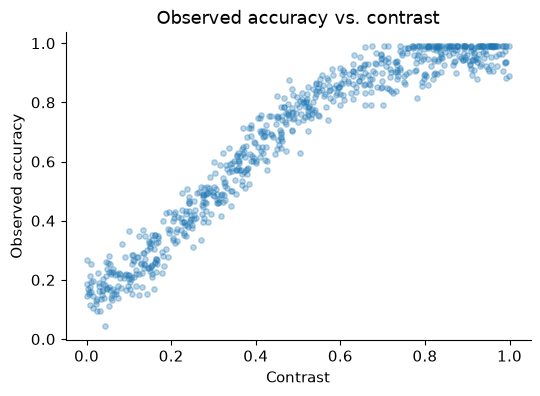

In [11]:
# Solution 4.3
# --- The realistic, noisy observable
r_p, p_p = stats.pearsonr(df["contrast"], df["accuracy_obs"])
r_s, p_s = stats.spearmanr(df["contrast"], df["accuracy_obs"])
print("Using accuracy_obs (noisy, realistic):")
print(f"  Pearson  r = {r_p:.3f}, p = {p_p:.2e}")
print(f"  Spearman r = {r_s:.3f}, p = {p_s:.2e}")

# --- The noiseless sigmoid, for comparison only
r_p2, _ = stats.pearsonr(df["contrast"], df["accuracy_prob"])
r_s2, _ = stats.spearmanr(df["contrast"], df["accuracy_prob"])
print("\nUsing accuracy_prob (noiseless, for comparison):")
print(f"  Pearson  r = {r_p2:.3f}")
print(f"  Spearman r = {r_s2:.3f}   <-- exactly 1.000")

fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["accuracy_obs"], alpha=0.3, s=15)
ax.set_xlabel("Contrast")
ax.set_ylabel("Observed accuracy")
ax.set_title("Observed accuracy vs. contrast")
plt.show()
# accuracy_obs rises monotonically with contrast but flattens near 1 -- an S-shaped, nonlinear
# trend. Spearman (rank-based) therefore captures the monotonic relationship slightly better
# than Pearson, which understates it because of the curvature and the ceiling.
#
# accuracy_prob gives Spearman = 1.000 exactly, because it was BUILT as a strictly increasing
# function of contrast with no noise. That number reflects the simulation code, not behaviour:
# it says "this variable is a perfect function of contrast", which is true by construction and
# would never occur in real data. Reporting it would be reporting an artefact.


**▶ Task 4.3 — Response: (Write your response in this Markdown cell)**

<a id="section-5"></a>
## 5. Linear regression: model, design matrix, least squares, inference

A simple linear regression models the outcome as $y = \beta_0 + \beta_1 x + \varepsilon$, where $\beta_0$ is the intercept, $\beta_1$ the slope, and $\varepsilon$ the residual noise. `statsmodels` estimates $\beta_0$ and $\beta_1$ by **least squares**: the values that minimise the sum of squared residuals. Internally, it builds a **design matrix** — a table with one column of 1s (for the intercept) and one column per predictor — and solves for the coefficients using that matrix.

### The least squares criterion

For each trial $i$, the model makes a prediction $\hat{y}_i = \beta_0 + \beta_1 x_i$, and the **residual** is the gap between the observed and predicted value, $e_i = y_i - \hat{y}_i$. Least squares picks the coefficients $\beta_0, \beta_1$ that minimise the **sum of squared residuals** (also called the residual sum of squares, RSS) over all $n$ trials:

$$
\text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2
$$

We square the residuals so that positive and negative errors don't cancel out, and so that large errors are penalised disproportionately more than small ones (a point we'll come back to in Section 11, when a few large residuals end up dominating the fit).

### Why it has a closed-form solution

$\text{RSS}(\beta_0, \beta_1)$ is a smooth, bowl-shaped (quadratic, convex) function of $\beta_0$ and $\beta_1$, so it has a single minimum, found where its partial derivatives with respect to $\beta_0$ and $\beta_1$ are both zero. Solving that pair of equations for the single-predictor case gives the familiar formulas

$$
\hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

where $\bar{x}$ and $\bar{y}$ are the sample means of $x$ and $y$. Notice the numerator of $\hat{\beta}_1$ is (proportional to) the covariance of $x$ and $y$, and the denominator is the variance of $x$ — the least-squares slope is essentially a rescaled covariance, which is also why it's closely related to the Pearson correlation from Section 4.

### The design-matrix (matrix) form

This is exactly what `statsmodels` computes, but written more generally so it extends directly to multiple predictors, polynomial terms (Section 9), and interactions (Section 9). Stack the intercept column of 1s and the predictor(s) into the design matrix $X$ (an $n \times p$ matrix, one row per trial, one column per parameter), and stack the outcomes into a vector $\mathbf{y}$. The model is then

$$
\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

and the least-squares estimate $\hat{\boldsymbol{\beta}}$ that minimises $\lVert \mathbf{y} - X\boldsymbol{\beta} \rVert^2$ (the matrix version of the RSS above) has the closed-form solution

$$
\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}
$$

known as the **normal equations**. `sm.OLS(y, X).fit()` solves precisely this equation (using a numerically stable method rather than literally inverting $X^{\top}X$) — so `model.params` are $\hat{\boldsymbol{\beta}}$, and `model.fittedvalues` are $X\hat{\boldsymbol{\beta}}$.


> **▶ Task 5.1 ⭐ — Fit a linear model.**
> Run the cell below, which fits a regression of `reaction_time` on `contrast` (using `sm.add_constant` to add the intercept column) and prints `model.summary()`. What are the intercept and slope, and how would you describe each in one sentence?


In [12]:
# TODO 5.1 — run this and answer the question below
X = sm.add_constant(df["contrast"])
y = df["reaction_time"]
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     515.2
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           2.11e-86
Time:                        16:21:16   Log-Likelihood:                 205.30
No. Observations:                 720   AIC:                            -406.6
Df Residuals:                     718   BIC:                            -397.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9432      0.013     70.869      0.0

**Model answer (TA edition).** The intercept (~0.9 s) is the model's predicted reaction time at zero contrast; the slope on contrast (~ −0.5) means each unit increase in contrast lowers predicted RT by about half a second. Both are highly significant (very small *p*-values), so contrast is a strong linear predictor of reaction time.


**▶ Task 5.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 5.2 ⭐ — Inspect the design matrix.**
> Print the first few rows of `X` (the design matrix built above). What does `sm.add_constant` actually add, and why is it needed to estimate an intercept?


In [13]:
# TODO 5.2 — write your code here



In [14]:
# Solution 5.2
print(X.head())
print("\nShape of design matrix:", model.model.exog.shape)
# sm.add_constant() prepends a column of 1s, which lets the model estimate an
# intercept (the constant term) alongside the slope on 'contrast'.


   const  contrast
0    1.0  0.288146
1    1.0  0.909594
2    1.0  0.213385
3    1.0  0.452124
4    1.0  0.931206

Shape of design matrix: (720, 2)


**▶ Task 5.2 — Response: (Write your response in this Markdown cell)**

For reference, `statsmodels` also offers an R-style **formula** interface, which builds the same design matrix for you from a string:


In [15]:
# --- Equivalent fit using the formula API
formula_model = smf.ols("reaction_time ~ contrast", data=df).fit()
print(formula_model.params)


Intercept    0.943185
contrast    -0.526366
dtype: float64


> **▶ Task 5.3 ⭐⭐ — Inference on the slope.**
> The summary table reports more than just the slope. Reconstruct that inference yourself from the fitted `model`: extract the slope $\hat{\beta}_1$ on `contrast`, its **standard error**, form the **t-statistic** $t = \hat{\beta}_1 / \text{SE}$, read off the **p-value**, and get the **95% confidence interval**. Check that your numbers match the `contrast` row of `model.summary()`.
> *Useful attributes:* `model.params`, `model.bse`, `model.tvalues`, `model.pvalues`, `model.conf_int()`.


In [16]:
# TODO 5.3 — write your code here
# Reconstruct: beta_1, its standard error, t = beta_1/SE, the p-value, and the 95% CI.



In [17]:
# Solution 5.3
beta1 = model.params["contrast"]
se1 = model.bse["contrast"]
t1 = beta1 / se1
p1 = model.pvalues["contrast"]
ci_low, ci_high = model.conf_int().loc["contrast"]

print(f"beta_1 (slope) : {beta1:.4f}")
print(f"standard error : {se1:.4f}")
print(f"t = beta_1/SE  : {t1:.3f}   (statsmodels: {model.tvalues['contrast']:.3f})")
print(f"p-value        : {p1:.3e}")
print(f"95% CI         : [{ci_low:.4f}, {ci_high:.4f}]")
# These reproduce the 'contrast' row of model.summary(): coef, std err, t, P>|t|, and [0.025, 0.975].
# t is large and the CI is far from 0, so the slope is significantly different from zero.


beta_1 (slope) : -0.5264
standard error : 0.0232
t = beta_1/SE  : -22.699   (statsmodels: -22.699)
p-value        : 2.114e-86
95% CI         : [-0.5719, -0.4808]


**▶ Task 5.3 — Response: (Write your response in this Markdown cell)**

<a id="section-6"></a>
## 6. Design matrices: a worked example

Section 5 introduced the design matrix $X$ in the abstract: a column of 1s for the intercept, plus one column per predictor, so that $\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}$. Let's make this completely concrete on a tiny toy dataset — small enough to print the whole matrix and check the arithmetic by hand — before trusting `statsmodels` to build it for us on the full dataset.


In [18]:
# --- A tiny toy dataset: 5 "trials" with a known, hand-checkable pattern
toy = pd.DataFrame({
    "contrast": [0.1, 0.3, 0.5, 0.7, 0.9],
    "reaction_time": [0.78, 0.68, 0.60, 0.52, 0.42],
})

# Build the design matrix by hand: a column of 1s, then a column per predictor
X_toy = np.column_stack([
    np.ones(len(toy)),   # intercept column
    toy["contrast"],     # one column for the "contrast" predictor
])
y_toy = toy["reaction_time"].values

print("Design matrix X_toy (intercept column | contrast column):")
print(X_toy)


Design matrix X_toy (intercept column | contrast column):
[[1.  0.1]
 [1.  0.3]
 [1.  0.5]
 [1.  0.7]
 [1.  0.9]]


Each **row** of `X_toy` is one trial; each **column** is one parameter of the model. Row $i$, dotted with the coefficient vector $\boldsymbol{\beta} = (\beta_0, \beta_1)$, gives that trial's prediction $\hat{y}_i = \beta_0 \cdot 1 + \beta_1 \cdot x_i$ — which is exactly why the intercept needs its own column of constant 1s: it's just a predictor that never changes.

Now let's solve the normal equations from Section 5, $\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}$, by hand with `numpy`, and check that we get the same answer as `sm.OLS`.


In [19]:
# --- Solve the normal equations by hand, then compare to sm.OLS
beta_hand = np.linalg.inv(X_toy.T @ X_toy) @ X_toy.T @ y_toy
print("beta from normal equations (by hand):", beta_hand)

toy_model = sm.OLS(y_toy, X_toy).fit()
print("beta from sm.OLS:                    ", toy_model.params)


beta from normal equations (by hand): [ 0.82 -0.44]
beta from sm.OLS:                     [ 0.82 -0.44]


The two match (up to floating-point rounding) — `sm.OLS` is solving exactly the equation from Section 5, just with a numerically safer algorithm than a literal matrix inverse.

### Adding more columns: categorical predictors

The real power of the design-matrix view is that it scales to more than one predictor without changing the recipe at all — every extra predictor is just one more column. This includes **categorical** predictors, like `subject_id`: instead of a single numeric column, a categorical variable with $k$ levels gets turned into $k-1$ **dummy (indicator) columns** (one level is left out as the *reference level*, so the intercept represents that reference level, and each dummy coefficient represents the *offset* from it). `statsmodels`'s formula interface (`C(...)`) builds these dummy columns for us automatically — this is what happens under the hood in Section 9's `contrast * C(subject_id)` interaction model.

Let's see it explicitly on a small slice of subjects:


In [20]:
# --- See the dummy-coded design matrix statsmodels builds for a categorical predictor
toy_subjects = pd.DataFrame({
    "contrast": [0.2, 0.6, 0.2, 0.6, 0.2, 0.6],
    "subject_id": ["S01", "S01", "S02", "S02", "S03", "S03"],
})

# patsy (statsmodels' formula engine) builds the design matrix for us
built = sm.regression.linear_model.OLS.from_formula(
    "reaction_time ~ contrast + C(subject_id)",
    data=toy_subjects.assign(reaction_time=0)  # placeholder outcome, we only want to inspect X
)
X_cat_named = pd.DataFrame(built.exog, columns=built.exog_names)
print(X_cat_named)


   Intercept  C(subject_id)[T.S02]  C(subject_id)[T.S03]  contrast
0        1.0                   0.0                   0.0       0.2
1        1.0                   0.0                   0.0       0.6
2        1.0                   1.0                   0.0       0.2
3        1.0                   1.0                   0.0       0.6
4        1.0                   0.0                   1.0       0.2
5        1.0                   0.0                   1.0       0.6


Notice `subject_id = "S01"` gets **no** dummy column of its own: it *is* the reference level, absorbed into the intercept. The columns `C(subject_id)[T.S02]` and `C(subject_id)[T.S03]` are 1 exactly on the rows for that subject and 0 otherwise — each coefficient on those columns is the *difference* in intercept between that subject and S01.

**Reflection.** Whether it's a single numeric predictor, several numeric predictors, dummy-coded categorical levels, polynomial terms, or interactions, the design matrix treats them all the same way: as columns to be multiplied by coefficients and added together. Sections 9 and 10 build on this directly — a polynomial term or an interaction is nothing more than another column computed from the existing predictors before the same least-squares machinery is applied.


<a id="section-7"></a>
## 7. Residual diagnostics

A linear regression comes with assumptions: residuals should have roughly constant variance (homoscedasticity), be approximately normally distributed, and be uncorrelated with the fitted values. Two quick diagnostic plots let us check this by eye: **residuals vs. fitted values**, and a **Q-Q plot** of the residuals.


> **▶ Task 7.1 ⭐ — Residuals vs. fitted values.**
> Run the cell below, which plots `model.resid` against `model.fittedvalues` (using the model from Task 5.1) with a horizontal reference line at 0. What pattern would indicate a problem with the constant-variance assumption?


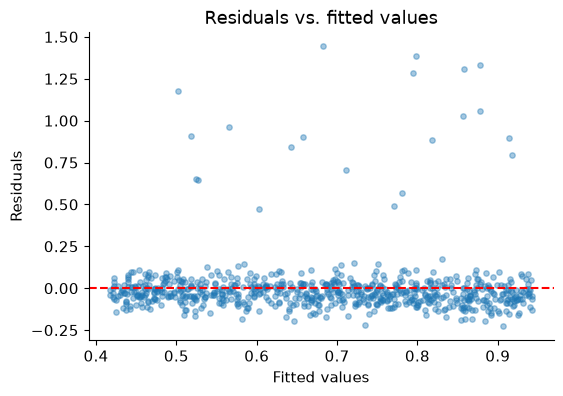

In [21]:
# TODO 7.1 — run this and answer the question below
fig, ax = plt.subplots()
ax.scatter(model.fittedvalues, model.resid, alpha=0.4, s=15)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. fitted values")
plt.show()


**Model answer (TA edition).** A *funnel* shape — the spread of the residuals growing or shrinking as the fitted value changes — would signal non-constant variance (heteroscedasticity). Here the residuals form a roughly flat band around 0, except for a few large positive residuals: the injected lapse trials.


**▶ Task 7.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 7.2 ⭐ — Q-Q plot of residuals.**
> Use `sm.qqplot(model.resid, line="45", fit=True)` to check whether the residuals look approximately normal. Do the "lapse" outlier trials we injected in Section 2 show up here, and if so, how?


In [22]:
# TODO 7.2 — write your code here



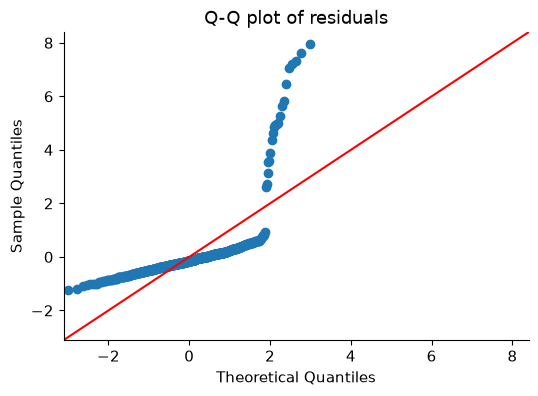

In [23]:
# Solution 7.2
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Q-Q plot of residuals")
plt.show()
# The lapse trials show up as a cluster of large positive residuals that deviate
# from the 45-degree line in the upper tail -- a sign of heavier-than-normal tails.


**▶ Task 7.2 — Response: (Write your response in this Markdown cell)**

**Reflection.** Beyond these two plots, it's also worth checking for influential points (Cook's distance — we'll do this in Section 11) and for correlation between residuals from the same subject, which a plain OLS model ignores.


<a id="section-8"></a>
## 8. When linear regression fails: circular relationships (synthetic add-on)

> **Note.** This section is a **self-contained synthetic add-on**: it uses the simulated `stim_angle`/`response_angle` variables and is *not* swapped for real data, because the IBL 2-alternative forced-choice task has no circular (orientation/phase) variable. The lesson — that ordinary linear regression cannot handle variables that wrap around — is general and worth seeing at least once.

Recall the `stim_angle` vs. `response_angle` scatter plot from Task 3.2 — angles wrap around at 360°, so 359° and 1° are actually close together, but an ordinary linear model has no notion of that.


> **▶ Task 8.1 ⭐⭐ — Fit a (bad) linear model to circular data.**
> Run the cell below, which fits `sm.OLS` of `response_angle` on `stim_angle` and overlays the fitted line on the scatter plot. Where does the fit look reasonable, and where does it clearly fail? Why?


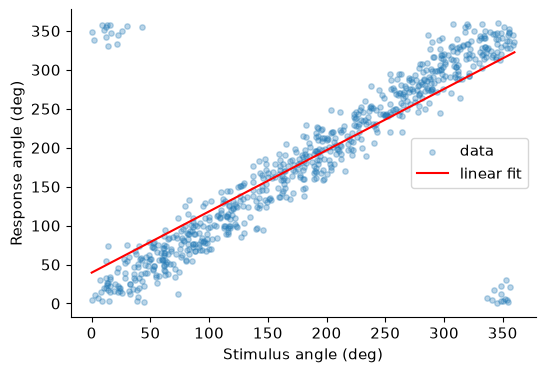

In [24]:
# TODO 8.1 — run this and answer the question below
X_angle = sm.add_constant(df["stim_angle"])
angle_model = sm.OLS(df["response_angle"], X_angle).fit()

fig, ax = plt.subplots()
ax.scatter(df["stim_angle"], df["response_angle"], alpha=0.3, s=15, label="data")
xs = np.linspace(0, 360, 200)
ax.plot(xs, angle_model.params["const"] + angle_model.params["stim_angle"] * xs,
        color="red", label="linear fit")
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.legend()
plt.show()


**Model answer (TA edition).** The line fits reasonably through the middle of the range but fails badly near 0°/360°: because angles wrap around, points near 0° and near 360° are geometrically close, yet the linear model treats them as maximally far apart. It cannot follow the wrap, so it systematically mis-predicts at the boundaries of the range.


**▶ Task 8.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 8.2 ⭐⭐⭐ — Work in sine/cosine space (optional).**
> Convert `stim_angle` and `response_angle` to `sin`/`cos` components (`np.sin(np.deg2rad(...))`, `np.cos(np.deg2rad(...))`), then fit two linear models predicting `resp_sin` and `resp_cos` from `stim_sin` and `stim_cos`. Why does this representation respect the circular geometry better than fitting on raw degrees?


In [25]:
# TODO 8.2 (optional) — write your code here



In [26]:
# Solution 8.2
df["stim_sin"] = np.sin(np.deg2rad(df["stim_angle"]))
df["stim_cos"] = np.cos(np.deg2rad(df["stim_angle"]))
df["resp_sin"] = np.sin(np.deg2rad(df["response_angle"]))
df["resp_cos"] = np.cos(np.deg2rad(df["response_angle"]))

circ_model_sin = smf.ols("resp_sin ~ stim_sin + stim_cos", data=df).fit()
circ_model_cos = smf.ols("resp_cos ~ stim_sin + stim_cos", data=df).fit()
print("Sin-transformed model")
print(circ_model_sin.params)
print("Cos-transformed model")
print(circ_model_cos.params)
# sin/cos map the angle onto the unit circle, where 359 deg and 1 deg are genuinely close.
# A predicted (sin, cos) pair can be turned back into an angle with arctan2, and there is no
# artificial discontinuity at 0/360 degrees -- the circular geometry is respected.


Sin-transformed model
Intercept    0.000518
stim_sin     0.939117
stim_cos    -0.012968
dtype: float64
Cos-transformed model
Intercept    0.011239
stim_sin     0.000538
stim_cos     0.946263
dtype: float64


**▶ Task 8.2 — Response: (Write your response in this Markdown cell)**

<a id="section-9"></a>
## 9. Polynomial terms and interactions

Adding polynomial terms (e.g. `contrast**2`) lets a linear model capture curvature; adding **interaction** terms (e.g. `contrast * subject`) lets the slope of one predictor depend on the level of another. Both are powerful, and both can overfit if used carelessly — more terms will (mechanically) improve the fit to the data you have, without necessarily reflecting the true underlying process. As such, they would be very poor at generalising.


> **▶ Task 9.1 ⭐⭐ — Linear vs. quadratic fit.**
> Observed accuracy is a sigmoidal function of contrast. The cell below fits a linear model and a quadratic model of `accuracy_obs` on `contrast`, and plots both fitted curves over the data. Run it. Does the quadratic term help (compare $R^2$)? Would a higher-order polynomial help more, or would it just be fitting noise?


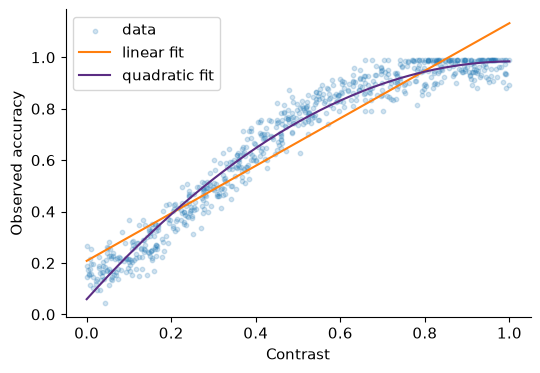

Linear R-squared:    0.9080597965598215
Quadratic R-squared: 0.9650587676798003
Difference between the two fits: 0.05699897111997876


In [27]:
# TODO 9.1 — run this and answer the question below
linear_fit = smf.ols("accuracy_obs ~ contrast", data=df).fit()
quad_fit = smf.ols("accuracy_obs ~ contrast + I(contrast**2)", data=df).fit()

xs = np.linspace(0, 1, 200)
pred_linear = linear_fit.predict(pd.DataFrame({"contrast": xs}))
pred_quad = quad_fit.predict(pd.DataFrame({"contrast": xs}))

fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["accuracy_obs"], alpha=0.2, s=10, label="data")
ax.plot(xs, pred_linear, color="C1", label="linear fit")
ax.plot(xs, pred_quad, color="C2", label="quadratic fit")
ax.set_xlabel("Contrast")
ax.set_ylabel("Observed accuracy")
ax.legend()
plt.show()

print("Linear R-squared:   ", linear_fit.rsquared)
print("Quadratic R-squared:", quad_fit.rsquared)
print("Difference between the two fits:", quad_fit.rsquared - linear_fit.rsquared)


**Model answer (TA edition).** The quadratic term captures curvature the straight line misses, so $R^2$ rises noticeably (roughly 0.91 to 0.97) and the $\text{contrast}^2$ coefficient is strongly significant. But neither polynomial reproduces the true sigmoidal *saturation*: a parabola must eventually turn back down, whereas real accuracy flattens out against a ceiling. Pushing to ever-higher-order polynomials would keep nudging $R^2$ up mechanically while fitting noise rather than the real S-shaped process — a job better handled by a logistic/GLM model, which you will meet next week.


**▶ Task 9.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 9.2 ⭐⭐ — An interaction with subject.**
> Fit `reaction_time ~ contrast * C(subject_id)` and print the first 10 estimated coefficients. What does one of the interaction coefficients tell you? With 12 subjects, how many extra parameters does this interaction add, and why should you be cautious about adding many interaction terms as the number of conditions grows?


In [28]:
# TODO 9.2 — write your code here



In [29]:
# Solution 9.2
interaction_fit = smf.ols("reaction_time ~ contrast * C(subject_id)", data=df).fit()
print(interaction_fit.params.head(10))
# Each interaction coefficient represents how much that subject's contrast-slope
# differs from the reference subject's slope. With 12 subjects we already add 12
# extra parameters; with many more subjects/conditions, interactions multiply
# quickly, using up degrees of freedom and making the model harder to interpret and
# prone to overfitting. A mixed-effects model is often a better tool for subject-level
# variability than manually adding interaction terms -- you will see this next week, stay tuned!


Intercept             1.009395
C(subject_id)[T.1]   -0.091897
C(subject_id)[T.2]   -0.030290
C(subject_id)[T.3]   -0.052821
C(subject_id)[T.4]   -0.107814
C(subject_id)[T.5]   -0.094293
C(subject_id)[T.6]   -0.013120
C(subject_id)[T.7]   -0.112632
C(subject_id)[T.8]   -0.047383
C(subject_id)[T.9]    0.042375
dtype: float64


**▶ Task 9.2 — Response: (Write your response in this Markdown cell)**

<a id="section-10"></a>
## 10. Train/test split and cross-validation: inference vs. prediction

So far every model has been fit on the whole dataset and interpreted through its coefficients — that's *inference*. If the goal is instead *prediction* (generalising to new trials), we need to check performance on data the model hasn't seen.


> **▶ Task 10.1 ⭐⭐ — A basic train/test split.**
> The cell below defines a helper `r_squared`, splits `df` into an 80% train and 20% test set, fits `reaction_time ~ contrast` on the training set only, and computes $R^2$ on both sets. Run it. Are the two values similar? Explain why.


In [30]:
# TODO 10.1 — run this and answer the question below
def r_squared(fit, data, target):
    '''Helper function to calculate the R-squared of a fitted model on a dataset.'''
    preds = fit.predict(data)
    ss_res = np.sum((data[target] - preds) ** 2)
    ss_tot = np.sum((data[target] - data[target].mean()) ** 2)
    return 1 - ss_res / ss_tot

train_df, test_df = train_test_split(df, test_size=0.2, random_state=7)
train_fit = smf.ols("reaction_time ~ contrast", data=train_df).fit()

print("Train R-squared:", r_squared(train_fit, train_df, "reaction_time"))
print("Test  R-squared:", r_squared(train_fit, test_df, "reaction_time"))


Train R-squared: 0.44017731823833517
Test  R-squared: 0.34386081342253083


**Model answer (TA edition).** Train and test $R^2$ are close because the simple linear model is well-specified and not overfitting: it captures a real, stable relationship, so it performs about equally on seen and unseen trials.


**▶ Task 10.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 10.2 ⭐⭐ — Overfitting with polynomial degree.**
> For polynomial degrees 1, 2, 4, and 8, fit `reaction_time` as a polynomial in `contrast` on `train_df`, and print the train and test $R^2$ for each. What happens to each as the degree increases, and how does that illustrate the difference between fitting for inference vs. fitting for prediction?


In [31]:
# TODO 10.2 — write your code here



In [32]:
# Solution 10.2
for degree in [1, 2, 4, 8]:
    formula = "reaction_time ~ " + " + ".join(
        [f"I(contrast**{d})" for d in range(1, degree + 1)]
    )
    fit_d = smf.ols(formula, data=train_df).fit()
    train_r2 = r_squared(fit_d, train_df, "reaction_time")
    test_r2 = r_squared(fit_d, test_df, "reaction_time")
    print(f"Degree {degree}: train R2 = {train_r2:.3f}, test R2 = {test_r2:.3f}")
# As degree increases, train R-squared tends to increase (or stay flat) while test
# R-squared can plateau or even decrease -- a classic sign of overfitting.


Degree 1: train R2 = 0.440, test R2 = 0.344
Degree 2: train R2 = 0.441, test R2 = 0.343
Degree 4: train R2 = 0.441, test R2 = 0.345
Degree 8: train R2 = 0.442, test R2 = 0.339


**▶ Task 10.2 — Response: (Write your response in this Markdown cell)**

> **▶ Task 10.3 ⭐⭐⭐ — Cross-validation.**
> A single train/test split is noisy — the estimate depends on which 20% happened to land in the test set. **k-fold cross-validation** averages over several splits: partition the data into $k$ folds, and for each fold, train on the other $k-1$ and test on the held-out fold. Using `sklearn`'s `KFold` (already imported), estimate the cross-validated $R^2$ (mean and standard deviation across folds) for polynomial degrees 1, 2, 4, and 8. Which degree generalises best, and how does the *variability* across folds change with degree?


In [33]:
# TODO 10.3 — write your code here
# Hint: KFold(n_splits=5, shuffle=True, random_state=7).split(df) yields (train_idx, test_idx).
# Reuse the r_squared helper from Task 10.1.



In [34]:
# Solution 10.3
def cv_r2(degree, data, n_splits=5, seed=7):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    formula = "reaction_time ~ " + " + ".join([f"I(contrast**{d})" for d in range(1, degree + 1)])
    scores = []
    for train_idx, test_idx in kf.split(data):
        tr, te = data.iloc[train_idx], data.iloc[test_idx]
        fit = smf.ols(formula, data=tr).fit()
        scores.append(r_squared(fit, te, "reaction_time"))
    return np.mean(scores), np.std(scores)

for degree in [1, 2, 4, 8]:
    m, s = cv_r2(degree, df)
    print(f"Degree {degree}: CV R2 = {m:.3f} +/- {s:.3f}")
# Cross-validation averages over several train/test splits, giving a less noisy estimate of
# out-of-sample performance than a single split. The low-degree model generalises as well or
# better, while high degrees tend to show lower and MORE VARIABLE CV R2 -- the signature of overfitting.


Degree 1: CV R2 = 0.433 +/- 0.094
Degree 2: CV R2 = 0.433 +/- 0.094
Degree 4: CV R2 = 0.429 +/- 0.094
Degree 8: CV R2 = 0.424 +/- 0.093


**▶ Task 10.3 — Response: (Write your response in this Markdown cell)**

<a id="section-11"></a>
## 11. Robust regression: outliers and influential points

Recall the "lapse" trials injected into `reaction_time` back in Section 2 — a small fraction of unusually slow trials. Ordinary least squares minimises *squared* error, so a handful of extreme points can pull the fit disproportionately. **Robust regression** (e.g. M-estimation with Huber's T norm) downweights large residuals instead.


> **▶ Task 11.1 ⭐⭐ — OLS vs. robust regression.**
> Run the cell below, which fits `sm.OLS` and `sm.RLM` (with `sm.robust.norms.HuberT()`) of `reaction_time` on `contrast`, compares the two estimated slopes, and plots both fitted lines. Which line is pulled more by the lapse trials?


OLS slope:  -0.5263657175406005
RLM slope:  -0.49483392026123985


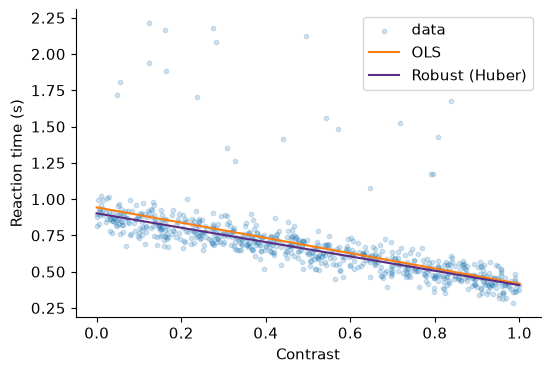

In [35]:
# TODO 11.1 — run this and answer the question below
X = sm.add_constant(df["contrast"])
y = df["reaction_time"]

ols_fit = sm.OLS(y, X).fit()
rlm_fit = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()

print("OLS slope: ", ols_fit.params["contrast"])
print("RLM slope: ", rlm_fit.params["contrast"])

xs = np.linspace(0, 1, 200)
Xs = sm.add_constant(xs)
fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["reaction_time"], alpha=0.2, s=10, label="data")
ax.plot(xs, ols_fit.predict(Xs), color="C1", label="OLS")
ax.plot(xs, rlm_fit.predict(Xs), color="C2", label="Robust (Huber)")
ax.set_xlabel("Contrast")
ax.set_ylabel("Reaction time (s)")
ax.legend()
plt.show()


**Model answer (TA edition).** The OLS line is pulled upward by the handful of large-RT lapse trials, because it minimises *squared* error and so large residuals dominate. The robust (Huber) fit down-weights those points, so its slope better reflects the bulk of the data.


**▶ Task 11.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 11.2 ⭐⭐ — Cook's distance.**
> Using `ols_fit.get_influence().cooks_distance`, find the 10 most influential trials in the OLS fit. Do they overlap with the `lapse_idx` trials we injected in Section 2?


In [36]:
# TODO 11.2 — write your code here



Indices of 10 most influential points: [483 290 127 129  97 451 361 331 553 557]
Overlap with injected lapse trials: 10


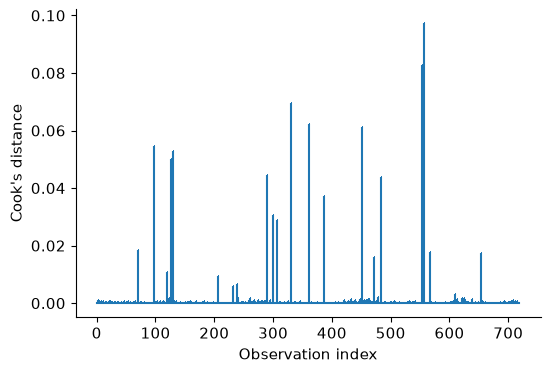

In [37]:
# Solution 11.2
influence = ols_fit.get_influence()
cooks_d, _ = influence.cooks_distance
top_influential = np.argsort(cooks_d)[-10:]
print("Indices of 10 most influential points:", top_influential)
print("Overlap with injected lapse trials:", len(set(top_influential) & set(lapse_idx)))

fig, ax = plt.subplots()
ax.stem(cooks_d, markerfmt=",")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
plt.show()
# We'd expect good overlap between the most influential points and the lapse trials
# we manually injected, confirming these outliers disproportionately affect the OLS fit.


**▶ Task 11.2 — Response: (Write your response in this Markdown cell)**

<a id="section-12"></a>
## 12. Putting it all together: a mini-analysis

This is the capstone challenge. Rather than following step-by-step instructions, you now run a small analysis end to end and finish with a **scientific conclusion** — the kind of short paragraph you might write in a results section.


> **▶ Task 12.1 ⭐⭐⭐ — From raw data to a scientific conclusion.**
> Investigate the question: **"Does stimulus contrast predict reaction time, and does that relationship generalise?"** Build a small pipeline that:
> 1. fits an OLS model of `reaction_time` on `contrast`, and reports the slope with its **95% confidence interval** (Section 5);
> 2. runs at least one **diagnostic or robustness check** — e.g. compare the OLS slope to a robust (`RLM`) slope, or inspect residuals (Sections 7, 11);
> 3. estimates **out-of-sample performance** with k-fold cross-validation (Section 10);
> 4. ends by **printing a 3–4 sentence scientific conclusion** that states the effect, its uncertainty, whether outliers drive it, and whether it generalises.
>
> There is no single right answer — you are assembling tools you have already used. Write your final interpretation in the Response cell as well.


In [38]:
# TODO 12.1 — write your end-to-end pipeline here
# Steps: (1) fit OLS + 95% CI, (2) a robustness/diagnostic check, (3) k-fold CV,
#        (4) print a short scientific conclusion.



In [39]:
# Solution 12.1 — one worked end-to-end pipeline
# Question: does stimulus contrast predict reaction time, and does it generalise?

# 1) Fit the model and get the slope + 95% CI
Xc = sm.add_constant(df["contrast"])
fit = sm.OLS(df["reaction_time"], Xc).fit()
slope = fit.params["contrast"]
ci_low, ci_high = fit.conf_int().loc["contrast"]

# 2) Robustness check: does a robust fit give a similar slope?
rlm = sm.RLM(df["reaction_time"], Xc, M=sm.robust.norms.HuberT()).fit()

# 3) Generalisation via 5-fold cross-validation (reusing r_squared from Task 10.1)
kf = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = []
for tr_idx, te_idx in kf.split(df):
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    f = smf.ols("reaction_time ~ contrast", data=tr).fit()
    cv_scores.append(r_squared(f, te, "reaction_time"))
cv_mean = np.mean(cv_scores)

print(f"OLS slope     : {slope:.3f} s per unit contrast (95% CI [{ci_low:.3f}, {ci_high:.3f}])")
print(f"Robust slope  : {rlm.params['contrast']:.3f} s per unit contrast")
print(f"5-fold CV R^2  : {cv_mean:.3f}")

# 4) Scientific conclusion
print(
    "\nScientific conclusion:\n"
    f"Reaction time decreases significantly with contrast: each unit of contrast lowers RT by\n"
    f"about {abs(slope):.2f} s, and the 95% confidence interval [{ci_low:.3f}, {ci_high:.3f}] excludes zero.\n"
    "The robust fit yields a very similar slope, so the effect is not an artefact of the few lapse\n"
    f"trials. Cross-validation shows the simple linear model generalises to unseen trials\n"
    f"(mean R^2 ~ {cv_mean:.2f}), so contrast is a reliable, generalisable predictor of reaction time."
)


OLS slope     : -0.526 s per unit contrast (95% CI [-0.572, -0.481])
Robust slope  : -0.495 s per unit contrast
5-fold CV R^2  : 0.433

Scientific conclusion:
Reaction time decreases significantly with contrast: each unit of contrast lowers RT by
about 0.53 s, and the 95% confidence interval [-0.572, -0.481] excludes zero.
The robust fit yields a very similar slope, so the effect is not an artefact of the few lapse
trials. Cross-validation shows the simple linear model generalises to unseen trials
(mean R^2 ~ 0.43), so contrast is a reliable, generalisable predictor of reaction time.


**▶ Task 12.1 — Response: (Write your response in this Markdown cell)**

<a id="section-13"></a>
## 13. Wrap-up and discussion

1. When would you report a Pearson correlation vs. a Spearman correlation in a paper, and why?
2. What does it mean for a regression to be used for *inference* rather than *prediction*? Give one example of each from this notebook.
3. Why does a linear model struggle with circular variables like orientation or phase? What variables in your own data might have this property?
4. How do you decide how many polynomial terms are "enough" without just maximising train $R^2$? How does cross-validation help?
5. What would you look for in residual diagnostics to decide whether robust regression is warranted?

**Reflection.** Every section in this notebook followed the same arc: *look at the data → summarise the relationship → fit a model → check whether the model's assumptions hold → decide whether the model is meant to explain or to predict*. That arc doesn't change as datasets grow from a few hundred simulated trials to real multi-subject behavioural datasets — only the size of the numbers involved does.

> **TA notes for the final version.** (1) Replace the simulation cell in Section 2 with `pd.read_csv(...)`; a few field names will be renamed downstream, and the dataset author has offered to help map them. Keep the column names (`contrast`, `reaction_time`, `correct_choice`, `subject_id`) consistent with what's used throughout. (2) The IBL 2AFC task has **no** circular variable, so Section 8 stays a self-contained synthetic add-on rather than being swapped for real data. (3) `accuracy_prob` is the noiseless sigmoid and is deliberately **never** analysed (it would give Spearman = 1.000 exactly); all accuracy analyses use `accuracy_obs`, which adds trial-level attentional noise and a ceiling. In the real dataset, map `accuracy_obs` onto whatever continuous performance measure is available (e.g. a session- or block-level accuracy rate), or model `correct_choice` directly with logistic regression. (4) If `correct_choice` (binary) is modelled directly in a future week, a short logistic-regression / GLM bridge would connect naturally to Task 9.1.


**▶ Task Section 13 — Response: (Write your response in this Markdown cell)**